Dataset folders:
 - /content/q12_data/LibriSpeech
 - /content/q12_data/Noises

Example files:
Speech: /content/q12_data/LibriSpeech/dev-clean/5338/284437/5338-284437-0008.flac
Noise : /content/q12_data/Noises/NoiseX-92/pink.wav

Listening order per SNR: clean → noisy → enhanced



=== Target SNR: 0 dB ===
Measured SNR in :   0.28 dB
Measured SNR out:   7.89 dB
SNR improvement :   7.60 dB


Saved: /content/q12_data/outputs/noisy_0dB.wav and /content/q12_data/outputs/enh_0dB.wav

=== Target SNR: 5 dB ===
Measured SNR in :   5.00 dB
Measured SNR out:   8.85 dB
SNR improvement :   3.85 dB


Saved: /content/q12_data/outputs/noisy_5dB.wav and /content/q12_data/outputs/enh_5dB.wav

=== Target SNR: 10 dB ===
Measured SNR in :  10.00 dB
Measured SNR out:   9.62 dB
SNR improvement :  -0.38 dB


Saved: /content/q12_data/outputs/noisy_10dB.wav and /content/q12_data/outputs/enh_10dB.wav


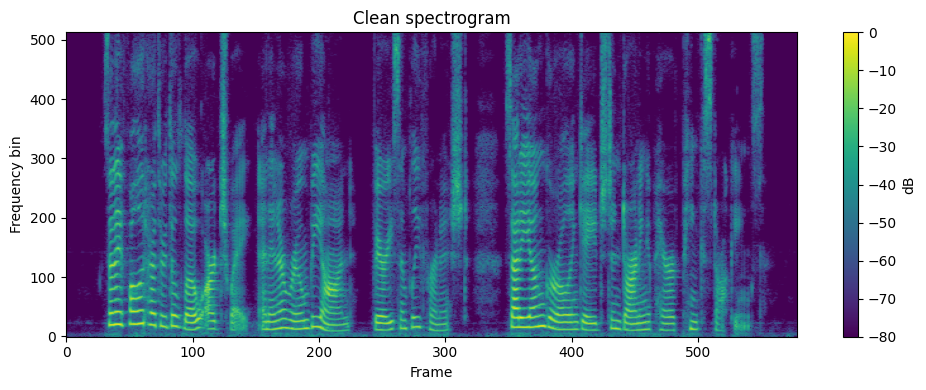

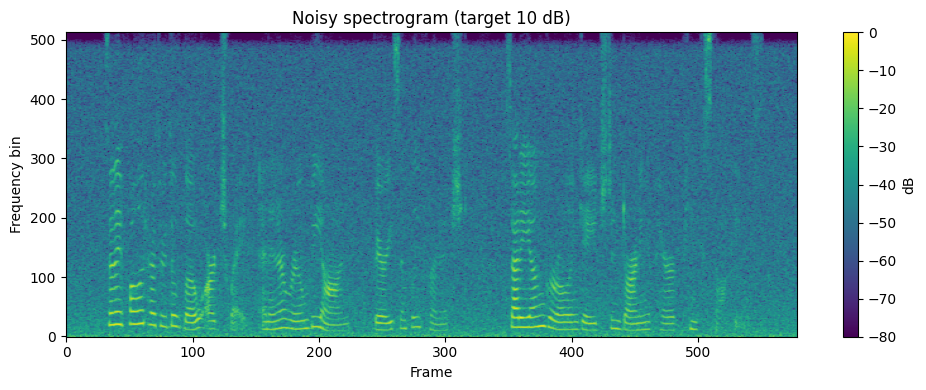

In [ ]:
# ============================================================
# Spectral Subtraction with REAL datasets (Colab)
# Downloads:
#  - Clean speech: LibriSpeech dev-clean (OpenSLR, CC BY 4.0)
#  - Noise: NOISEX-92 WAV copy from a public research repo (GitHub)
# ============================================================

import os, glob, random, subprocess, math
import numpy as np

# --- Install deps ---
subprocess.check_call(["bash", "-lc", "pip -q install librosa soundfile"])
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

random.seed(0)
np.random.seed(0)

# -----------------------
# 1) Download datasets
# -----------------------
DATA_DIR = "/content/q12_data"
os.makedirs(DATA_DIR, exist_ok=True)

# LibriSpeech dev-clean (OpenSLR)
LIBRI_URL = "https://openslr.trmal.net/resources/12/dev-clean.tar.gz"
LIBRI_TGZ = os.path.join(DATA_DIR, "dev-clean.tar.gz")
LIBRI_ROOT = os.path.join(DATA_DIR, "LibriSpeech")  # created by tar

# NOISEX-92 wav copy (GitHub repo)
NOISE_REPO = "https://github.com/speechdnn/Noises.git"
NOISE_ROOT = os.path.join(DATA_DIR, "Noises")       # git clone target

def sh(cmd: str):
    subprocess.check_call(["bash", "-lc", cmd])

# Download LibriSpeech if needed
if not os.path.isdir(LIBRI_ROOT):
    if not os.path.isfile(LIBRI_TGZ):
        sh(f"wget -nc -O '{LIBRI_TGZ}' '{LIBRI_URL}'")
    sh(f"tar -xzf '{LIBRI_TGZ}' -C '{DATA_DIR}'")

# Clone noises repo if needed
if not os.path.isdir(NOISE_ROOT):
    sh(f"git clone --depth 1 '{NOISE_REPO}' '{NOISE_ROOT}'")

print("Dataset folders:")
print(" -", LIBRI_ROOT)
print(" -", NOISE_ROOT)

# -----------------------
# 2) Pick files
# -----------------------
# LibriSpeech dev-clean is FLAC
SPEECH_GLOB = os.path.join(LIBRI_ROOT, "dev-clean", "**", "*.flac")
speech_files = sorted(glob.glob(SPEECH_GLOB, recursive=True))
assert len(speech_files) > 0, f"No speech files found at {SPEECH_GLOB}"

# NOISEX-92 WAVs (repo layout: Noises/NoiseX-92/**.wav)
NOISE_GLOB = os.path.join(NOISE_ROOT, "NoiseX-92", "**", "*.wav")
noise_files = sorted(glob.glob(NOISE_GLOB, recursive=True))
assert len(noise_files) > 0, f"No noise wav files found at {NOISE_GLOB}"

speech_path = random.choice(speech_files)
noise_path  = random.choice(noise_files)

print("\nExample files:")
print("Speech:", speech_path)
print("Noise :", noise_path)

# -----------------------
# 3) Audio utilities
# -----------------------
SR = 16000

def load_audio(path: str, target_sr=SR) -> np.ndarray:
    x, sr = librosa.load(path, sr=target_sr, mono=True)  # handles FLAC/WAV
    x = x.astype(np.float32)
    # peak normalize
    peak = np.max(np.abs(x)) + 1e-12
    x = 0.95 * x / peak
    return x

def snr_db(clean: np.ndarray, test: np.ndarray) -> float:
    L = min(len(clean), len(test))
    clean = clean[:L].astype(np.float64)
    test  = test[:L].astype(np.float64)
    err = test - clean
    p_clean = np.mean(clean**2) + 1e-12
    p_err   = np.mean(err**2) + 1e-12
    return 10.0 * np.log10(p_clean / p_err)

def mix_at_snr(clean: np.ndarray, noise: np.ndarray, snr_target_db: float):
    L = len(clean)
    if len(noise) < L:
        reps = int(np.ceil(L / len(noise)))
        noise = np.tile(noise, reps)

    start = np.random.randint(0, len(noise) - L + 1)
    noise_seg = noise[start:start+L]

    p_clean = np.mean(clean**2) + 1e-12
    p_noise = np.mean(noise_seg**2) + 1e-12

    p_noise_target = p_clean / (10.0 ** (snr_target_db / 10.0))
    scale = np.sqrt(p_noise_target / p_noise)

    noise_scaled = scale * noise_seg
    noisy = clean + noise_scaled

    # prevent clipping
    mx = np.max(np.abs(noisy)) + 1e-12
    if mx > 1.0:
        noisy = noisy / mx
        noise_scaled = noise_scaled / mx

    return noisy.astype(np.float32), noise_scaled.astype(np.float32)

# -----------------------
# 4) Spectral subtraction
# -----------------------
def spectral_subtraction(
    noisy: np.ndarray,
    noise_ref: np.ndarray,
    sr: int = SR,
    n_fft: int = 1024,
    hop: int = 256,
    win: int = 1024,
    alpha: float = 2.5,   # over-subtraction factor
    beta: float = 0.01,   # spectral floor (reduces musical noise)
    smooth: bool = True
) -> np.ndarray:
    Y = librosa.stft(noisy, n_fft=n_fft, hop_length=hop, win_length=win, window="hann", center=True)
    D = librosa.stft(noise_ref, n_fft=n_fft, hop_length=hop, win_length=win, window="hann", center=True)

    Y_mag2 = (np.abs(Y) ** 2)
    D_mag2 = (np.abs(D) ** 2)

    # noise PSD estimate (mean over time)
    noise_psd = np.mean(D_mag2, axis=1, keepdims=True)  # (freq, 1)

    # subtract in power domain + floor
    X_mag2 = Y_mag2 - alpha * noise_psd
    floor = beta * noise_psd
    X_mag2 = np.maximum(X_mag2, floor)

    # light smoothing to reduce musical noise
    if smooth:
        X = X_mag2
        X = (X + np.roll(X, 1, 0) + np.roll(X, -1, 0) + np.roll(X, 1, 1) + np.roll(X, -1, 1)) / 5.0
        X_mag2 = X

    X_mag = np.sqrt(X_mag2 + 1e-12)
    X_hat = X_mag * np.exp(1j * np.angle(Y))  # noisy phase

    enh = librosa.istft(X_hat, hop_length=hop, win_length=win, window="hann", length=len(noisy))
    enh = enh.astype(np.float32)

    peak = np.max(np.abs(enh)) + 1e-12
    enh = 0.95 * enh / peak
    return enh

def alpha_for_snr(snr_db_target: float) -> float:
    # stronger subtraction at lower SNR
    return float(np.interp(snr_db_target, [0, 10], [3.0, 2.0]))

# -----------------------
# 5) Run experiment at SNR = 0, 5, 10 dB
# -----------------------
clean = load_audio(speech_path, target_sr=SR)
noise = load_audio(noise_path,  target_sr=SR)

# noise-only reference segment for noise PSD estimate (first up to 5 sec)
noise_ref = noise[: min(len(noise), 5*SR)]

snr_targets = [0, 5, 10]

out_dir = os.path.join(DATA_DIR, "outputs")
os.makedirs(out_dir, exist_ok=True)

print("\nListening order per SNR: clean → noisy → enhanced")
display(Audio(clean, rate=SR))

results = []
for snr_t in snr_targets:
    noisy, _ = mix_at_snr(clean, noise, snr_t)

    enh = spectral_subtraction(
        noisy=noisy,
        noise_ref=noise_ref,
        alpha=alpha_for_snr(snr_t),
        beta=0.01,
        smooth=True
    )

    snr_in  = snr_db(clean, noisy)
    snr_out = snr_db(clean, enh)
    imp = snr_out - snr_in
    results.append((snr_t, snr_in, snr_out, imp))

    print(f"\n=== Target SNR: {snr_t} dB ===")
    print(f"Measured SNR in : {snr_in:6.2f} dB")
    print(f"Measured SNR out: {snr_out:6.2f} dB")
    print(f"SNR improvement : {imp:6.2f} dB")

    # Save wavs
    noisy_path = os.path.join(out_dir, f"noisy_{snr_t}dB.wav")
    enh_path   = os.path.join(out_dir, f"enh_{snr_t}dB.wav")
    sf.write(noisy_path, noisy, SR)
    sf.write(enh_path,   enh,   SR)

    display(Audio(noisy, rate=SR))
    display(Audio(enh, rate=SR))
    print("Saved:", noisy_path, "and", enh_path)

# -----------------------
# 6) Quick spectrogram view (last SNR case)
# -----------------------
def plot_power_spec(x, title, n_fft=1024, hop=256):
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop))**2
    S_db = librosa.power_to_db(S, ref=np.max)
    plt.figure(figsize=(10, 4))
    plt.imshow(S_db, aspect="auto", origin="lower")
    plt.title(title)
    plt.xlabel("Frame")
    plt.ylabel("Frequency bin")
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()

last_snr = snr_targets[-1]
noisy_last, _ = mix_at_snr(clean, noise, last_snr)
enh_last = spectral_subtraction(noisy_last, noise_ref, alpha=alpha_for_snr(last_snr), beta=0.01, smooth=True)

plot_power_spec(clean,     "Clean spectrogram")
plot_power_spec(noisy_last, f"Noisy spectrogram (target {last_snr} dB)")
plot_power_spec(enh_last,   "Enhanced spectrogram (spectral subtraction)")
